In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/Customer-Retention-Analysis"

df = pd.read_csv(
    f"{BASE_PATH}/data/processed/clean_merged_data.csv"
)

df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp']
)

Create Cohort Month

In [2]:
df['cohort_month'] = df.groupby(
    'customer_unique_id'
)['order_purchase_timestamp'].transform(
    'min'
).dt.to_period('M')

Create Order Month

In [5]:
df['order_month'] = df[
    'order_purchase_timestamp'
].dt.to_period('M')

Create Cohort Index

In [6]:
year_diff = (
    df['order_month'].dt.year -
    df['cohort_month'].dt.year
)

month_diff = (
    df['order_month'].dt.month -
    df['cohort_month'].dt.month
)

df['cohort_index'] = (
    year_diff * 12 +
    month_diff + 1
)

Create Cohort Data Table

In [7]:
cohort_data = df.groupby(
    ['cohort_month', 'cohort_index']
)['customer_unique_id'].nunique().reset_index()

cohort_data.head()

,cohort_month,cohort_index,customer_unique_id
0,2016-09,1,1
1,2016-10,1,262
2,2016-10,7,1
3,2016-10,10,1
4,2016-10,12,1


Create Retention Matrix

In [8]:
retention_matrix = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer_unique_id'
)

retention_matrix.head()

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,262.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,717.0,2.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1628.0,3.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,3.0,NaN,NaN


Convert Retention Counts into Percentages

In [9]:
retention_matrix = retention_matrix.divide(
    retention_matrix.iloc[:, 0],
    axis=0
)

retention_matrix.head()

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003817,NaN,NaN,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,0.007634,0.007634
2016-12,1.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.002789,0.002789,0.001395,0.004184,0.001395,0.004184,0.001395,0.001395,NaN,0.004184,0.001395,0.006974,0.004184,0.001395,0.001395,0.002789,0.004184,0.001395,NaN
2017-02,1.0,0.001843,0.003071,0.001229,0.004300,0.001229,0.002457,0.001843,0.001229,0.001843,0.001229,0.003071,0.001229,0.001843,0.001229,0.000614,0.000614,0.001843,NaN,NaN


Create Cohort Retention Heatmap

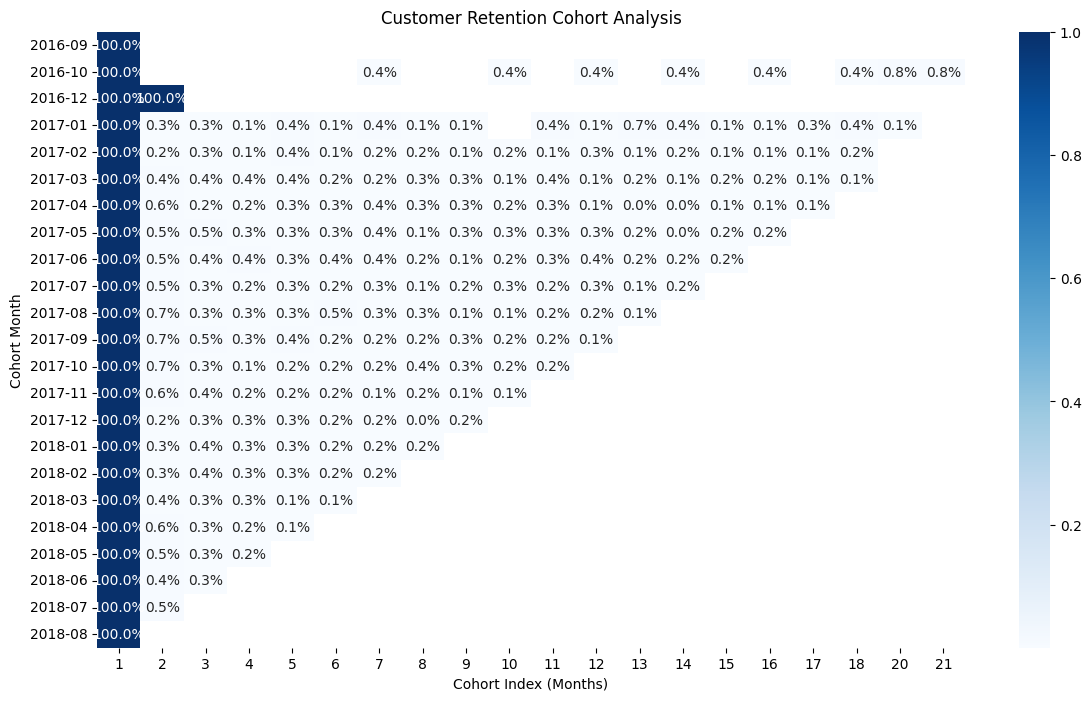

In [18]:
plt.figure(figsize=(14,8))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1%',
    cmap='Blues'
)

plt.title("Customer Retention Cohort Analysis")
plt.xlabel("Cohort Index (Months)")
plt.ylabel("Cohort Month")

plt.show()